In [4]:
import pandas as pd
import numpy as np
import yaml

In [5]:
data = pd.read_csv('data.csv', encoding='utf-8')
data.head(1)

,Unnamed: 0,id,label,statement,date,subject,speaker,speaker_description,state_info,true_counts,...,false_counts,pants_on_fire_counts,context,justification,type,valid,sum_true,sum_false,result,Words_Statement
0,0,21750,1,Three doctors from the same hospital 'die sudd...,"July 28, 2022",facebook fact-checks;coronavirus,the gateway pundit,The Gateway Pundit is a conservative website.,NaN,1,...,15,3,a post,""" Segall’s obituary said he died ""after a un...",test,NaN,3,21,False,22


In [ ]:

data['length_statem'] = data['statement'].str.len()
data['length_justif']=data["justification"].str.len()
data.head(1)

,Unnamed: 0,id,label,statement,date,subject,speaker,speaker_description,state_info,true_counts,...,context,justification,type,valid,sum_true,sum_false,result,Words_Statement,length_statem,length_justif
0,0,21750,1,Three doctors from the same hospital 'die sudd...,"July 28, 2022",facebook fact-checks;coronavirus,the gateway pundit,The Gateway Pundit is a conservative website.,NaN,1,...,a post,""" Segall’s obituary said he died ""after a un...",test,NaN,3,21,False,22,139,544


In [7]:
correlation = data['length_statem'].corr(data['length_justif'])
correlation

np.float64(0.18222502973992089)

In [8]:
data['face_check'] = data['subject'].str.contains('facebook', na=False)
data.head(1)

,Unnamed: 0,id,label,statement,date,subject,speaker,speaker_description,state_info,true_counts,...,justification,type,valid,sum_true,sum_false,result,Words_Statement,length_statem,length_justif,face_check
0,0,21750,1,Three doctors from the same hospital 'die sudd...,"July 28, 2022",facebook fact-checks;coronavirus,the gateway pundit,The Gateway Pundit is a conservative website.,NaN,1,...,""" Segall’s obituary said he died ""after a un...",test,NaN,3,21,False,22,139,544,True


In [9]:
correlation = data['sum_false'].corr(data['face_check'])
correlation

np.float64(0.754294002871929)

In [ ]:


correlation2 = data['sum_false'].corr(data['speaker_description'].str.contains('social', na=False))
correlation2

np.float64(0.897810134913745)

In [11]:
correlation3 = data['sum_false'].corr(data['length_statem'])
correlation3

np.float64(-0.0892245684439155)

In [12]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split

df = pd.DataFrame(data)
print("Исходный датасет:")
print(df)
print("\n" + "="*50 + "\n")

Исходный датасет:
       Unnamed: 0     id  label  \
0               0  21750      1   
1               1  18173      0   
2               2  22673      1   
3               3   9897      1   
4               4   3855      3   
...           ...    ...    ...   
22957       22957   7463      4   
22958       22958   3540      3   
22959       22959  21773      1   
22960       22960  10605      3   
22961       22961   7497      5   

                                               statement               date  \
0      Three doctors from the same hospital 'die sudd...      July 28, 2022   
1                          Say Joe Biden is a pedophile.      July 17, 2020   
2      A photo shows President Joe Biden and Ukrainia...  February 20, 2023   
3      It will cost $50,000 per enrollee in Obamacare...   January 27, 2015   
4      The Federal Register - which houses all Washin...      June 14, 2011   
...                                                  ...                ...   
22957  W

In [13]:
vectorizer = TfidfVectorizer(ngram_range=(1,2))
vectorizer.fit(data['statement'])
x_train = vectorizer.transform(data[data['type']=='train']['statement'])
x_test = vectorizer.transform(data[data['type']=='test']['statement'])
y_train = data[data['type']=='train']['result'].astype(int)
y_test = data[data['type']=='test']['result'].astype(int)

def f1_result(data):
    try:
        with open('results2.yaml', 'r', encoding='utf-8') as f:
            yaml_data = yaml.safe_load(f) or []
    except FileNotFoundError:
        yaml_data = []    
    yaml_data.append(data)
    
    with open('results2.yaml', 'w', encoding='utf-8') as f:
        yaml.dump(yaml_data, f, allow_unicode=True, default_flow_style=False, sort_keys=False)

In [14]:
print("Размерности после векторизации:")
print(f"X_train: {x_train.shape}")
print(f"X_test: {x_test.shape}")
print(f"Количество уникальных слов: {len(vectorizer.get_feature_names_out())}")

Размерности после векторизации:
X_train: (18369, 181548)
X_test: (2296, 181548)
Количество уникальных слов: 181548


In [15]:
from sklearn.metrics import accuracy_score, classification_report
from sklearn.svm import LinearSVC
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.naive_bayes import MultinomialNB, ComplementNB
from sklearn.linear_model import LogisticRegression, SGDClassifier

model = ComplementNB(norm=False)
model.fit(x_train, y_train)

,"alpha alpha: float or array-like of shape (n_features,), default=1.0Additive (Laplace/Lidstone) smoothing parameter(set alpha=0 and force_alpha=True, for no smoothing).",1.0
,"force_alpha force_alpha: bool, default=TrueIf False and alpha is less than 1e-10, it will set alpha to1e-10. If True, alpha will remain unchanged. This may causenumerical errors if alpha is too close to 0... versionadded:: 1.2.. versionchanged:: 1.4 The default value of `force_alpha` changed to `True`.",True
,"fit_prior fit_prior: bool, default=TrueOnly used in edge case with a single class in the training set.",True
,"class_prior class_prior: array-like of shape (n_classes,), default=NonePrior probabilities of the classes. Not used.",None
,"norm norm: bool, default=FalseWhether or not a second normalization of the weights is performed. Thedefault behavior mirrors the implementations found in Mahout and Weka,which do not follow the full algorithm described in Table 9 of thepaper.",False


In [16]:
from sklearn.metrics import f1_score
y_pred = model.predict(x_test)
f1 = f1_score(data[data['type'] == 'test']['result'].astype(int), y_pred, average='macro')
print(f1)
f1_result({"model": "ComplementNB", 'f1_score': f1})

0.7096570606524665


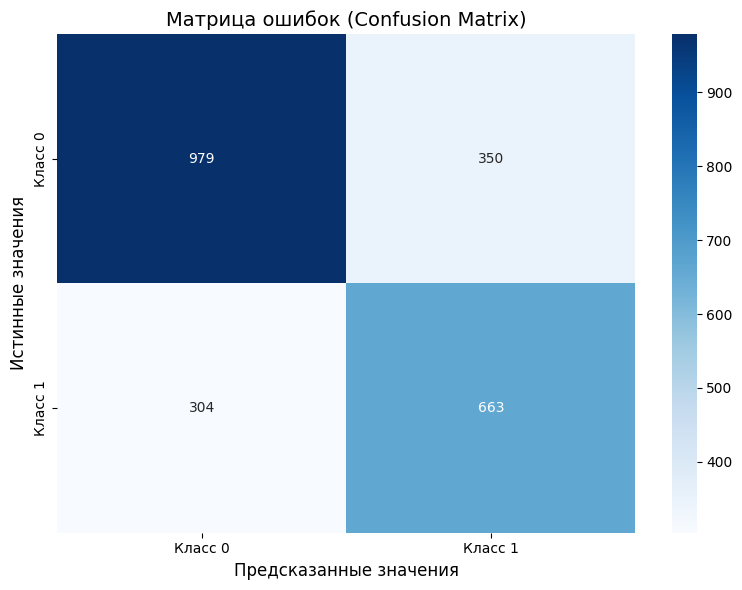

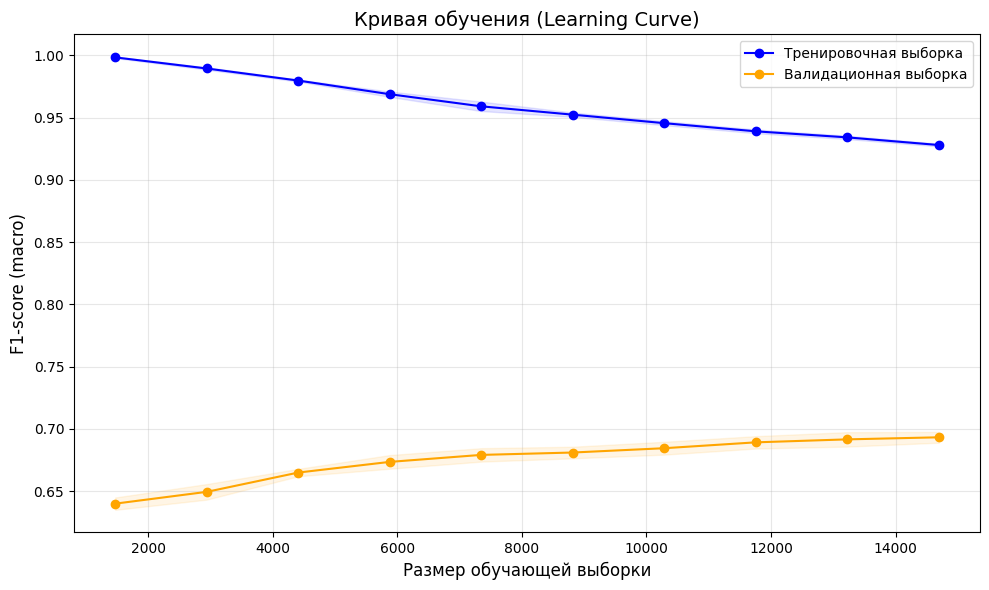

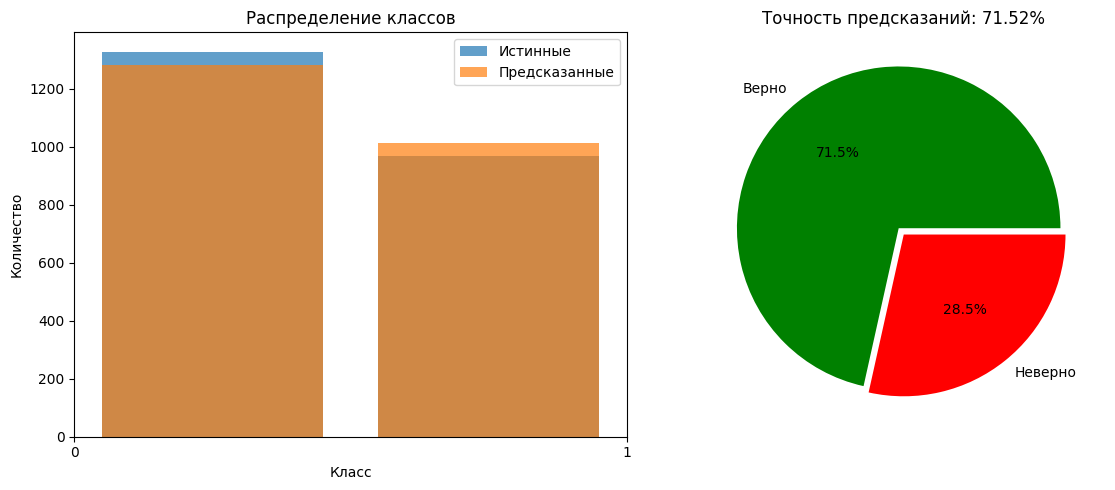

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix
from sklearn.model_selection import learning_curve
import numpy as np


cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=['Класс 0', 'Класс 1'],
            yticklabels=['Класс 0', 'Класс 1'])
plt.title('Матрица ошибок (Confusion Matrix)', fontsize=14)
plt.xlabel('Предсказанные значения', fontsize=12)
plt.ylabel('Истинные значения', fontsize=12)
plt.tight_layout()
plt.show()

train_sizes, train_scores, test_scores = learning_curve(
    model, x_train, y_train, cv=5, n_jobs=-1,
    train_sizes=np.linspace(0.1, 1.0, 10),
    scoring='f1_macro', random_state=42
)

train_mean = np.mean(train_scores, axis=1)
train_std = np.std(train_scores, axis=1)
test_mean = np.mean(test_scores, axis=1)
test_std = np.std(test_scores, axis=1)

plt.figure(figsize=(10, 6))
plt.fill_between(train_sizes, train_mean - train_std, train_mean + train_std, 
                 alpha=0.1, color='blue')
plt.fill_between(train_sizes, test_mean - test_std, test_mean + test_std, 
                 alpha=0.1, color='orange')
plt.plot(train_sizes, train_mean, 'o-', color='blue', label='Тренировочная выборка')
plt.plot(train_sizes, test_mean, 'o-', color='orange', label='Валидационная выборка')

plt.title('Кривая обучения (Learning Curve)', fontsize=14)
plt.xlabel('Размер обучающей выборки', fontsize=12)
plt.ylabel('F1-score (macro)', fontsize=12)
plt.legend(loc='best')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.hist(y_test, alpha=0.7, label='Истинные', bins=2, rwidth=0.8)
plt.hist(y_pred, alpha=0.7, label='Предсказанные', bins=2, rwidth=0.8)
plt.title('Распределение классов')
plt.xlabel('Класс')
plt.ylabel('Количество')
plt.legend()
plt.xticks([0, 1])

plt.subplot(1, 2, 2)
comparison = pd.DataFrame({'Истинные': y_test.values, 'Предсказанные': y_pred})
correct = (comparison['Истинные'] == comparison['Предсказанные']).sum()
wrong = len(comparison) - correct
plt.pie([correct, wrong], labels=['Верно', 'Неверно'], autopct='%1.1f%%',
        colors=['green', 'red'], explode=(0.05, 0))
plt.title(f'Точность предсказаний: {correct/len(comparison):.2%}')

plt.tight_layout()
plt.show()